# Chicago Housing Affordability Analysis

## Core metrics
- **PIR** (Payment-to-Income Ratio): monthly mortgage payment / monthly household income
- **PTI** (Price-to-Income Ratio): anchored home price / annual household income


In [13]:
import os
import numpy as np
from pathlib import Path
import pandas as pd
import geopandas as gpd
import altair as alt
from sklearn.linear_model import LinearRegression
from shapely import wkt
import matplotlib.pyplot as plt

os.makedirs('output', exist_ok=True)


In [14]:
# Data sources
urls = {
    'home_price': 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=CHXRSA',
    'mortgage_rate': 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US',
    'income_median': 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=MHIIL17000A052NCEN',
    'income_pc_real': 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=RPIPC16980',
    'permits': 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=CHIC917BPPRIVSA'
}

home = pd.read_csv(urls['home_price']).rename(columns={'observation_date':'date','CHXRSA':'home_price_index'})
mort = pd.read_csv(urls['mortgage_rate']).rename(columns={'observation_date':'date','MORTGAGE30US':'mortgage_rate'})
income_med = pd.read_csv(urls['income_median']).rename(columns={'observation_date':'date','MHIIL17000A052NCEN':'income_median'})
income_pc = pd.read_csv(urls['income_pc_real']).rename(columns={'observation_date':'date','RPIPC16980':'income_pc_real'})
permits = pd.read_csv(urls['permits']).rename(columns={'observation_date':'date','CHIC917BPPRIVSA':'permits'})

for df in [home,mort,income_med,income_pc,permits]:
    df['date']=pd.to_datetime(df['date'])


In [15]:
# Annualize and merge
start_date='2000-01-01'
home=home[home['date']>=start_date]
mort=mort[mort['date']>=start_date]
permits=permits[permits['date']>=start_date]
income_med=income_med[income_med['date']>=start_date]
income_pc=income_pc[income_pc['date']>=start_date]

home_y=home.set_index('date').resample('Y').mean().reset_index()
mort_y=mort.set_index('date').resample('Y').mean().reset_index()
permits_y=permits.set_index('date').resample('Y').mean().reset_index()

income_med['year']=income_med['date'].dt.year
income_pc['year']=income_pc['date'].dt.year
home_y['year']=home_y['date'].dt.year
mort_y['year']=mort_y['date'].dt.year
permits_y['year']=permits_y['date'].dt.year

merged=(home_y[['year','home_price_index']]
        .merge(mort_y[['year','mortgage_rate']],on='year',how='inner')
        .merge(income_med[['year','income_median']],on='year',how='inner')
        .merge(income_pc[['year','income_pc_real']],on='year',how='left')
        .merge(permits_y[['year','permits']],on='year',how='left')
        .dropna(subset=['home_price_index','mortgage_rate','income_median']))

merged=merged.sort_values('year').reset_index(drop=True)


/var/folders/vw/bx9xh51s10j65dpdhy55lq9h0000gn/T/ipykernel_38773/727683234.py:9: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  home_y=home.set_index('date').resample('Y').mean().reset_index()
/var/folders/vw/bx9xh51s10j65dpdhy55lq9h0000gn/T/ipykernel_38773/727683234.py:10: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  mort_y=mort.set_index('date').resample('Y').mean().reset_index()
/var/folders/vw/bx9xh51s10j65dpdhy55lq9h0000gn/T/ipykernel_38773/727683234.py:11: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  permits_y=permits.set_index('date').resample('Y').mean().reset_index()


In [16]:
# Build affordability metrics
# Anchored price proxy: choose baseline nominal price at first available year
P_BASE = 320_000
DOWN_PAYMENT = 0.20
N_MONTHS = 360

base_hpi = merged.loc[0,'home_price_index']
merged['home_price_proxy'] = P_BASE * (merged['home_price_index']/base_hpi)
merged['loan_amount'] = merged['home_price_proxy']*(1-DOWN_PAYMENT)
merged['r_month'] = (merged['mortgage_rate']/100)/12

# Mortgage payment formula
merged['mortgage_payment_monthly'] = merged['loan_amount'] * (
    merged['r_month']*(1+merged['r_month'])**N_MONTHS / ((1+merged['r_month'])**N_MONTHS - 1)
)

merged['income_monthly'] = merged['income_median']/12
# Payment-to-Income Ratio
merged['PIR'] = merged['mortgage_payment_monthly']/merged['income_monthly']
# Price-to-income Ratio
merged['PTI'] = merged['home_price_proxy']/merged['income_median']

# Normalized index
base_pir=merged.loc[0,'PIR']
merged['PIR_index']=merged['PIR']/base_pir*100


In [17]:
# Chart 1: trend overview (normalized)
plot_df=merged[['year','home_price_index','mortgage_rate','income_median']].copy()
for c in ['home_price_index','mortgage_rate','income_median']:
    plot_df[c+'_idx']=plot_df[c]/plot_df[c].iloc[0]*100

plot_long=plot_df.melt(id_vars=['year'],value_vars=['home_price_index_idx','mortgage_rate_idx','income_median_idx'],var_name='series',value_name='value')
plot_long['series']=plot_long['series'].map({'home_price_index_idx':'Home Price Index (norm)','mortgage_rate_idx':'Mortgage Rate (norm)','income_median_idx':'Median Income (norm)'})
chart1=alt.Chart(plot_long).mark_line().encode(x='year',y='value',color='series').properties(title='Chicago Housing Affordability Drivers (Normalized to 100)',width=500,height=250)
chart1.save('output/trend_overview_normalized.png')
chart1


alt.Chart(...)

In [ ]:
# Chart 2: PIR + PIR index
base=alt.Chart(merged)
left=base.mark_line(color='#1f77b4').encode(alt.X('year'),alt.Y('PIR',title='PIR'),color=alt.value('#1f77b4')).properties(width=500,height=250)
right=base.mark_line(strokeDash=[4,2],color='#d62728').encode(alt.X('year'),alt.Y('mortgage_rate',title='Mortgage Rate',axis=alt.Axis(orient='right')),color=alt.value('#d62728'))
chart2=alt.layer(left,right).resolve_scale(y='independent').properties(title='Core Affordability Metric: PIR and Mortgage Rate')
chart2.save('output/pir_main.png')
chart2


alt.LayerChart(...)

In [ ]:
# Chart 3: Correlation heatmap
corr_cols=['home_price_index','mortgage_rate','income_median','permits','PIR','PTI']
corr=merged[corr_cols].corr(numeric_only=True)
corr_long=corr.reset_index().melt(id_vars='index').rename(columns={'index':'x','variable':'y'})
chart3=alt.Chart(corr_long).mark_rect().encode(x=alt.X('x',title=''),y=alt.Y('y',title=''),color=alt.Color('value',scale=alt.Scale(domainMid=0,scheme='redblue',reverse=True),title='corr')).properties(title='Correlation Heatmap',width=400,height=350)
chart3=chart3+alt.Chart(corr_long).mark_text().encode(x='x',y='y',text=alt.Text('value',format='.2f'),color=alt.value('black'))
chart3.save('output/correlation_heatmap.png')
chart3


alt.LayerChart(...)

In [ ]:
hpi_chart=alt.Chart(merged).mark_line(color='blue').encode(alt.X('year'),alt.Y('home_price_index',title='Home Price Index'))
rate_chart=alt.Chart(merged).mark_line(color='red').encode(alt.X('year'),alt.Y('mortgage_rate',title='Mortgage Rate',axis=alt.Axis(orient='right')))
chart4=alt.layer(hpi_chart,rate_chart).resolve_scale(y='independent').properties(title='Home Price Index and Mortgage Rate Over Time')
chart3.save('output/price_and_rate.png')
chart4

alt.LayerChart(...)

In [ ]:
# Chart 4: scatter with regression (mortgage rate vs PIR)
X=merged[['mortgage_rate']]
y=merged['PIR']
reg=LinearRegression().fit(X,y)
merged['pir_pred_by_rate']=reg.predict(X)

order=np.argsort(merged['mortgage_rate'].values)
line_df=merged.iloc[order][['mortgage_rate','pir_pred_by_rate']].copy()
merged5=merged[(merged['mortgage_rate']>=2)&(merged['mortgage_rate']<=9)]
line_df=line_df[(line_df['mortgage_rate']>=2)&(line_df['mortgage_rate']<=9)]
x_enc=alt.X('mortgage_rate',title='Mortgage Rate (%)',scale=alt.Scale(domain=[2,9]))
y_enc=alt.Y('PIR',title='PIR',scale=alt.Scale(domain=[0.2,0.6]))
scatter_chart=alt.Chart(merged5).mark_circle(size=40,opacity=0.8).encode(x_enc,y_enc)
line_chart=alt.Chart(line_df).mark_line(color='red').encode(x_enc,alt.Y('pir_pred_by_rate',scale=alt.Scale(domain=[0.2,0.6])))
chart5=alt.layer(scatter_chart,line_chart).properties(title='Mortgage Rate vs PIR',width=400,height=250)
chart5.save('output/pir_vs_rate_regression.png')
chart5

print('Slope:', reg.coef_[0])
print('Intercept:', reg.intercept_)
print('R^2:', reg.score(X,y))
chart5


Slope: 0.06680891455265921
Intercept: 0.05189775888844317
R^2: 0.7853600801073992


alt.LayerChart(...)

In [ ]:
# Save updated annual table
merged.to_csv('output/merged_annual_updated.csv', index=False)
merged.tail()

,year,home_price_index,mortgage_rate,income_median,income_pc_real,permits,home_price_proxy,loan_amount,r_month,mortgage_payment_monthly,income_monthly,PIR,PTI,PIR_index,pir_pred_by_rate
20,2020,148.405477,3.111698,71243.0,60477.0,1256.116214,452470.449028,361976.359222,0.002593,1547.999273,5936.916667,0.260741,6.351086,53.316759,0.259787
21,2021,164.771937,2.957692,72215.0,62167.0,1529.794856,502369.818168,401895.854534,0.002465,1685.252638,6017.916667,0.280039,6.956585,57.262828,0.249498
22,2022,183.008395,5.344038,76744.0,59878.0,1433.657563,557970.584767,446376.467814,0.004453,2490.970746,6395.333333,0.389498,7.270543,79.645160,0.408927
23,2023,192.599684,6.806731,80346.0,62786.0,1181.536624,587213.271905,469770.617524,0.005672,3064.659472,6695.500000,0.457719,7.308556,93.595110,0.506648
24,2024,206.937817,6.721154,83327.0,NaN,1443.069769,630928.513242,504742.810594,0.005601,3264.079843,6943.916667,0.470063,7.571718,96.119216,0.500931


### Spatial Graph

In [ ]:
HERE = Path.cwd()
ROOT = HERE.parent
DATA_DIR = ROOT / "data" / "raw-data"
SAVE_DIR = ROOT / 'data' / 'output/'
df = pd.read_csv(DATA_DIR / "Zip_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")
df2 = pd.read_csv(DATA_DIR / "Boundaries_-_ZIP_Codes_20260301.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/nd/final-project-yuhang-jiuzhou/data/raw-data/Zip_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv'

df_cook_house_price.shape: (56, 322)
df2.head():
                                             the_geom  OBJECTID    ZIP  \
0  MULTIPOLYGON (((-87.64740454306485 41.88314614...         1  60607   
1  MULTIPOLYGON (((-87.64081267674514 41.88907723...         2  60661   
2  MULTIPOLYGON (((-87.63696184579966 41.88905665...         3  60606   
3  MULTIPOLYGON (((-87.58103206721337 41.80421129...         4  60615   
4  MULTIPOLYGON (((-87.66326342055945 41.72120432...         5  60643   

        SHAPE_AREA       SHAPE_LEN  
0  64,664,294.2344  39,143.6400726  
1   9,357,755.8171  13,132.5659184  
2  6,766,410.78996  12,040.4399607  
3  66,565,454.6108  38,321.3132699  
4  207,706,232.893  75,254.7301243  
Zillow Zip Code Number: 56
Map Zip Code Number: 59
Common Zip Code Number: 56
------------------------------
Zip Code Not in Zillow: {'60827', '60707', '60666'}


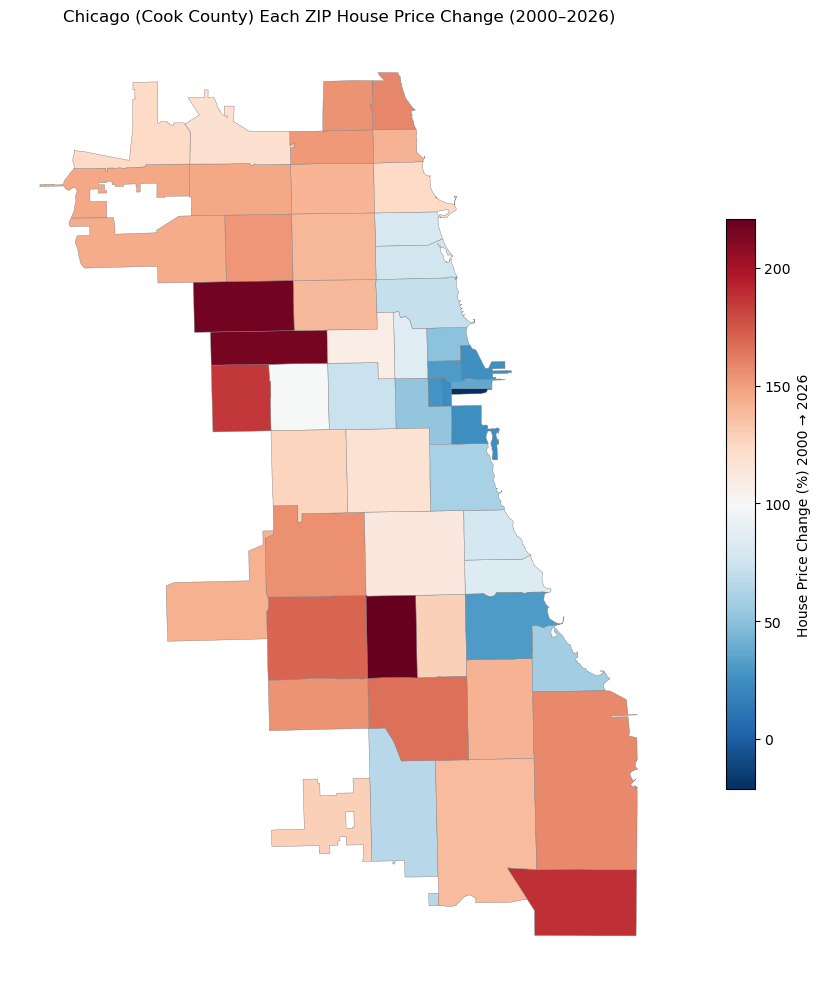

In [ ]:
df_cook_house_price = df[
    (df['CountyName'] == 'Cook County') & (df['StateName'] == 'IL') & (df['City'] == 'Chicago')
].copy()

print("df_cook_house_price.shape:", df_cook_house_price.shape)

print("df2.head():\n", df2.head())

zillow_zips = set(df_cook_house_price['RegionName'].astype(str).str.strip())
boundary_zips = set(df2['ZIP'].astype(str).str.strip())

common_zips = zillow_zips.intersection(boundary_zips)
only_in_zillow = zillow_zips - boundary_zips
only_in_boundary = boundary_zips - zillow_zips

print(f"Zillow Zip Code Number: {len(zillow_zips)}")
print(f"Map Zip Code Number: {len(boundary_zips)}")
print(f"Common Zip Code Number: {len(common_zips)}")
print("-" * 30)
print(f"Zip Code Not in Zillow: {only_in_boundary}")

df_cook_house_price['RegionName'] = df_cook_house_price['RegionName'].astype(str).str.strip()
date_cols = [c for c in df_cook_house_price.columns if '-' in str(c) and str(c)[:4].isdigit()]

long = df_cook_house_price.melt(
    id_vars=['RegionName'],
    value_vars=date_cols,
    var_name='date_str',
    value_name='price'
)
long['year'] = long['date_str'].astype(str).str[:4].astype(int)
long = long.dropna(subset=['price'])
df_annual = long.groupby(['RegionName', 'year'], as_index=False)['price'].mean()
df_annual = df_annual.rename(columns={'RegionName': 'ZIP'})


year_min = 2000
year_max = df_annual['year'].max()

p_2000 = df_annual[df_annual['year'] == year_min].rename(columns={'price': 'price_2000'})[['ZIP', 'price_2000']]
p_latest = df_annual[df_annual['year'] == year_max].rename(columns={'price': 'price_latest'})[['ZIP', 'price_latest']]

change = p_2000.merge(p_latest, on='ZIP', how='inner')
change['pct_change'] = (change['price_latest'] - change['price_2000']) / change['price_2000'].replace(0, np.nan)
change['pct_change_pct'] = change['pct_change'] * 100  # 百分比


df2['ZIP'] = df2['ZIP'].astype(str).str.strip()
geo = gpd.GeoDataFrame(df2, geometry=gpd.GeoSeries.from_wkt(df2['the_geom']), crs='EPSG:4326')
merged = geo.merge(change, on='ZIP', how='inner')

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
merged.plot(
    ax=ax,
    column='pct_change_pct',
    legend=True,
    cmap='RdBu_r',
    legend_kwds={'label': 'House Price Change (%) 2000 → ' + str(year_max), 'shrink': 0.6},
    edgecolor='gray',
    linewidth=0.3,
    missing_kwds={'color': 'lightgray', 'label': 'No Data'}
)
ax.set_title(f'Chicago (Cook County) Each ZIP House Price Change ({year_min}–{year_max})')
ax.axis('off')
plt.tight_layout()
plt.show()